In [1]:
# [setup]
# Renders the two FUTURE (draft August) lines that build_kpi_sheet_update.py writes into the
# KPI workbook's "Official Forecast Data" tab, one axis per product. This is a render check on
# the tab rows themselves -- it reads the generated CSV, NOT the parquets or the canonical
# curves -- so what you see here is what Looker will draw from the pasted rows.
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


def find_repo_root() -> Path:
    """Nearest ancestor holding pyproject.toml, so the notebook runs from any cwd.

    Sibling notebooks assume the repo root is the cwd (jupyter launched there); nbconvert
    instead runs with the notebook's own directory as cwd. Resolving explicitly makes both work.
    """
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(f"No pyproject.toml above {Path.cwd()} -- run inside the repo")


REPO_ROOT = find_repo_root()
KPI_SHEET_DIR = REPO_ROOT / "data-official/2026-08/kpi_sheet"
PLOTS_DIR = REPO_ROOT / "data-official/2026-08/plots"
FUTURE_ONLY_CSV = KPI_SHEET_DIR / "official_forecast_data.FUTURE_ONLY.csv"

FORECAST_START = pd.Timestamp("2026-08-02")  # August seam
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")  # Dec-15 headline
PREV_FORECAST_START = pd.Timestamp("2026-07-06")  # July's seam
# Gap days: the day before each superseded cycle's forecast start, nulled so that vintage's
# segment breaks off rather than connecting into the next one. The first four are inherited
# from the source tab; the JUN->JUL one is added by this cycle's build.
INHERITED_GAPS = [pd.Timestamp(d) for d in ("2026-01-31", "2026-02-28", "2026-03-31", "2026-05-25")]
JUL_HANDOFF = PREV_FORECAST_START - pd.Timedelta(days=1)  # 2026-07-05
EXPECTED_GAPS = sorted([*INHERITED_GAPS, JUL_HANDOFF])

PRIOR_NAME = "FUTURE prior forecasts"
FORECAST_NAME = "FUTURE forecast"


def millions_formatter(x, pos):
    # Two decimals so adjacent ~0.5M-spaced ticks stay distinct (e.g. 16.50M vs 17.00M) rather
    # than collapsing to identical whole-million labels. Matches the canonical notebook.
    return f"{x / 1e6:.2f}M"


print(f"repo root: {REPO_ROOT}")


repo root: /Users/brendanwells/work/mozaic-daily


In [2]:
# [load-future]
# One date-indexed Series per (product, line). NaNs are PRESERVED -- they are the handoff gaps
# that make each superseded cycle render as its own segment, so dropna() here would silently
# heal the very breaks this chart exists to check.
future = pd.read_csv(FUTURE_ONLY_CSV, parse_dates=["submission_date"])


def line(product: str, forecast_name: str) -> pd.Series:
    """The tab rows for one product/forecast_name as a date-indexed DAU series, gaps intact."""
    rows = future[(future["product"] == product) & (future["forecast_name"] == forecast_name)]
    return rows.set_index("submission_date")["dau_28_ma"].sort_index()


series = {
    (product, name): line(product, name)
    for product in ("desktop", "mobile")
    for name in (PRIOR_NAME, FORECAST_NAME)
}

for (product, name), s in series.items():
    gaps = sorted(s.index[s.isna()].strftime("%Y-%m-%d"))
    print(
        f"{product:8s} {name:24s} n={len(s):4d}  "
        f"{s.index.min().date()} -> {s.index.max().date()}  gaps={gaps}"
    )

# The chart's headline claim: every vintage renders as its own segment, and the seam handoff is
# a one-day step between two separate series. Assert both so a bad rebuild fails here.
for product in ("desktop", "mobile"):
    prior, forecast = series[(product, PRIOR_NAME)], series[(product, FORECAST_NAME)]
    assert sorted(prior.index[prior.isna()]) == EXPECTED_GAPS, f"{product}: unexpected gap days"
    step = forecast.loc[FORECAST_START] - prior.loc[FORECAST_START - pd.Timedelta(days=1)]
    # What the JUN->JUL gap is hiding: the two vintages' levels on the days either side of it.
    # Without the null day the line would connect these directly, drawing that as a spike.
    bridged = prior.loc[PREV_FORECAST_START] - prior.loc[JUL_HANDOFF - pd.Timedelta(days=1)]
    print(
        f"{product:8s} JUN->JUL disagreement broken by the gap {bridged:+12,.0f}   "
        f"JUL->AUG seam step {step:+12,.0f}"
    )


desktop  FUTURE prior forecasts   n= 213  2026-01-01 -> 2026-08-01  gaps=['2026-01-31', '2026-02-28', '2026-03-31', '2026-05-25', '2026-07-05']
desktop  FUTURE forecast          n= 152  2026-08-02 -> 2026-12-31  gaps=[]
mobile   FUTURE prior forecasts   n= 213  2026-01-01 -> 2026-08-01  gaps=['2026-01-31', '2026-02-28', '2026-03-31', '2026-05-25', '2026-07-05']
mobile   FUTURE forecast          n= 152  2026-08-02 -> 2026-12-31  gaps=[]
desktop  JUN->JUL disagreement broken by the gap     +895,841   JUL->AUG seam step   +1,955,351
mobile   JUN->JUL disagreement broken by the gap     +414,383   JUL->AUG seam step     +102,530


In [3]:
# [render]
def render_future_plot(product: str, title: str, savename: str, legend_loc: str = "lower left"):
    """Both FUTURE lines for one product on a single axis, with the junctions marked.

    Colours follow the workbook's own reading of the two lines: purple for the spliced
    as-published history (Looker draws it as the light-purple "Prior Forecasts" series) and
    green for the live forecast, matching the canonical notebook's "current cycle" colour.

    legend_loc differs per product because the two curves occupy opposite corners: desktop
    falls through the year and leaves the lower left empty, mobile rises and leaves the upper
    left empty. A shared default would sit on top of the data on one of them.
    """
    prior = series[(product, PRIOR_NAME)]
    forecast = series[(product, FORECAST_NAME)]

    # The two junctions this chart exists to show: the JUN->JUL handoff, where the null day
    # breaks the line rather than letting it connect across the vintages' level disagreement,
    # and the JUL->AUG seam, which is a handoff between two separate series.
    bridged = prior.loc[PREV_FORECAST_START] - prior.loc[JUL_HANDOFF - pd.Timedelta(days=1)]
    seam_step = forecast.loc[FORECAST_START] - prior.loc[FORECAST_START - pd.Timedelta(days=1)]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(prior.index, prior.values, color="purple", linewidth=1.3,
            label=f"{PRIOR_NAME} (as-published history, Jan 1 - Aug 1)")
    ax.plot(forecast.index, forecast.values, color="green", linewidth=1.8,
            label=f"{FORECAST_NAME} (August cycle, seam - Dec 31)")

    for i, gap in enumerate(INHERITED_GAPS):
        ax.axvline(gap, color="grey", linestyle="-", alpha=0.25, linewidth=1,
                   label="inherited handoff gap (line breaks)" if i == 0 else None)
    ax.axvline(JUL_HANDOFF, color="darkorange", linestyle="-.", alpha=0.9, linewidth=1.4,
               label=f"JUN->JUL gap {JUL_HANDOFF.date()} - breaks {bridged:+,.0f} disagreement")
    ax.axvline(FORECAST_START, color="grey", linestyle="--", alpha=0.7,
               label=f"August seam {FORECAST_START.date()} ({seam_step:+,.0f} across lines)")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")

    dec15 = forecast.loc[MEASUREMENT_DATE]
    ax.plot(MEASUREMENT_DATE, dec15, marker="D", color="gold", markersize=11,
            markeredgecolor="black", markeredgewidth=0.8, linestyle="None",
            label=f"Dec-15 {dec15:,.0f}")

    ax.set_title(title, fontsize=13)
    ax.set_ylabel("DAU (28-day MA)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(loc=legend_loc, fontsize=9, framealpha=0.92)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = f"{PLOTS_DIR}/{savename}"
    fig.savefig(out, dpi=130)
    print(f"saved: {out}")
    plt.show()


saved: /Users/brendanwells/work/mozaic-daily/data-official/2026-08/plots/kpi_sheet_future_desktop.png


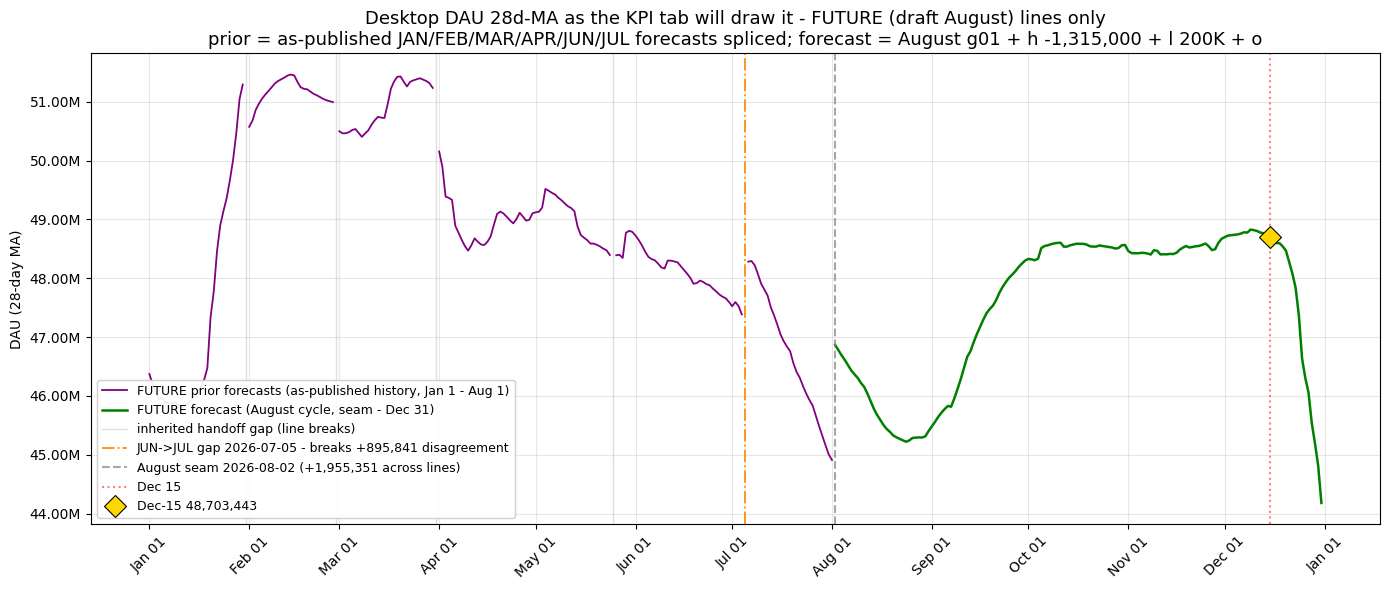

In [4]:
# [plot-desktop-future]
render_future_plot(
    "desktop",
    title=("Desktop DAU 28d-MA as the KPI tab will draw it - FUTURE (draft August) lines only\n"
           "prior = as-published JAN/FEB/MAR/APR/JUN/JUL forecasts spliced; forecast = August g01 "
           "+ h -1,315,000 + l 200K + o"),
    savename="kpi_sheet_future_desktop.png",
)


saved: /Users/brendanwells/work/mozaic-daily/data-official/2026-08/plots/kpi_sheet_future_mobile.png


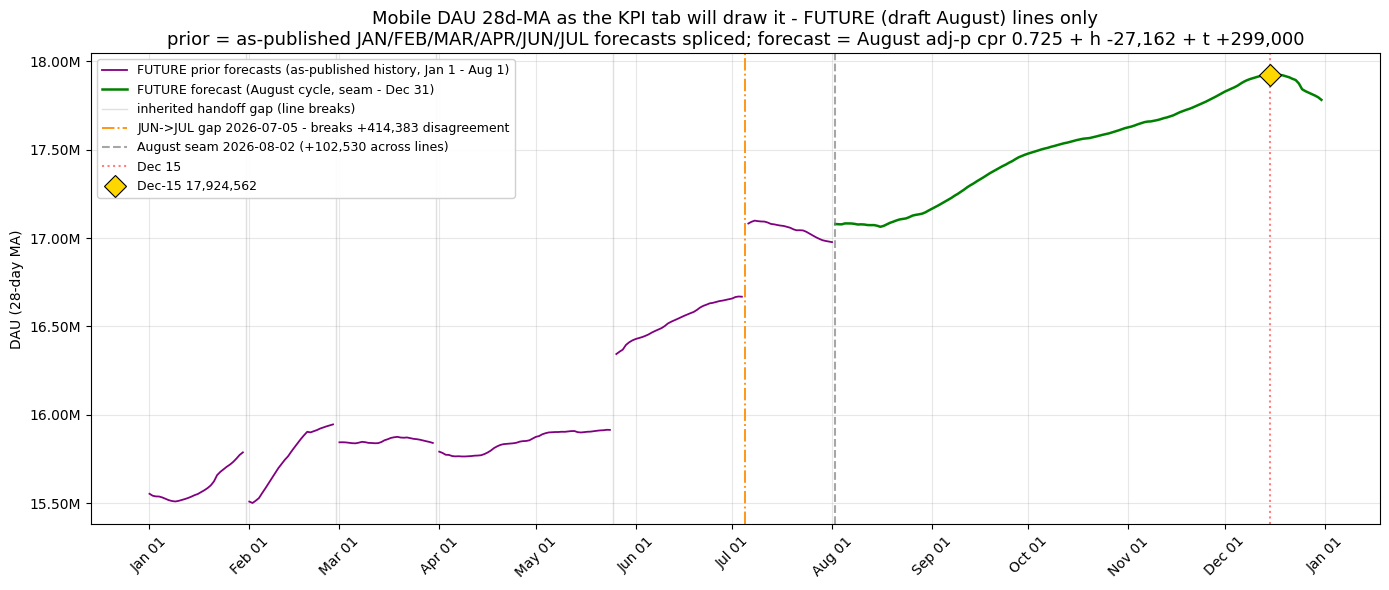

In [5]:
# [plot-mobile-future]
render_future_plot(
    "mobile",
    title=("Mobile DAU 28d-MA as the KPI tab will draw it - FUTURE (draft August) lines only\n"
           "prior = as-published JAN/FEB/MAR/APR/JUN/JUL forecasts spliced; forecast = August "
           "adj-p cpr 0.725 + h -27,162 + t +299,000"),
    savename="kpi_sheet_future_mobile.png",
    legend_loc="upper left",  # mobile rises through the year; lower left sits on the data
)
